<a href="https://colab.research.google.com/github/kanak-coder123/DSA-prep/blob/main/FlightPricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''from google.colab import files
uploaded=files.upload()'''

Saving Data_Train.xlsx to Data_Train.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_excel('Data_Train.xlsx')
df.to_csv('Data_Train.csv', index=False)

print("Conversion completed!")

Conversion completed!


In [ ]:
df=pd.read_csv('Data_Train.csv')
print(df)

           Airline Date_of_Journey    Source Destination  \
0           IndiGo      24/03/2019  Banglore   New Delhi   
1        Air India       1/05/2019   Kolkata    Banglore   
2      Jet Airways       9/06/2019     Delhi      Cochin   
3           IndiGo      12/05/2019   Kolkata    Banglore   
4           IndiGo      01/03/2019  Banglore   New Delhi   
...            ...             ...       ...         ...   
10678     Air Asia       9/04/2019   Kolkata    Banglore   
10679    Air India      27/04/2019   Kolkata    Banglore   
10680  Jet Airways      27/04/2019  Banglore       Delhi   
10681      Vistara      01/03/2019  Banglore   New Delhi   
10682    Air India       9/05/2019     Delhi      Cochin   

                       Route Dep_Time  Arrival_Time Duration Total_Stops  \
0                  BLR → DEL    22:20  01:10 22 Mar   2h 50m    non-stop   
1      CCU → IXR → BBI → BLR    05:50         13:15   7h 25m     2 stops   
2      DEL → LKO → BOM → COK    09:25  04:25 10 Jun

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


Checking missing value and duplicates


In [ ]:
df.isnull().sum()


,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df.duplicated().sum()

np.int64(220)

In [ ]:
df = df.drop_duplicates()
df = df.dropna()
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])
df["Journey_Day"] = df["Date_of_Journey"].dt.day
df["Journey_Month"] = df["Date_of_Journey"].dt.month

/tmp/ipykernel_12469/4035459779.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])


In [ ]:
df = df.drop("Date_of_Journey", axis=1)

In [ ]:
df["Dep_Time"] = pd.to_datetime(df["Dep_Time"])

df["Dep_Hour"] = df["Dep_Time"].dt.hour
df["Dep_Min"] = df["Dep_Time"].dt.minute

df.drop("Dep_Time",axis=1,inplace=True)

/tmp/ipykernel_12469/193773363.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_Time"] = pd.to_datetime(df["Dep_Time"])


In [ ]:
df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"])

df["Arrival_Hour"] = df["Arrival_Time"].dt.hour
df["Arrival_Min"] = df["Arrival_Time"].dt.minute

df.drop("Arrival_Time",axis=1,inplace=True)

/tmp/ipykernel_12469/2052425560.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_Time"] = pd.to_datetime(df["Arrival_Time"])


In [ ]:
def convert_duration(duration):

    hours = 0
    mins = 0

    if "h" in duration:
        hours = int(duration.split("h")[0])

    if "m" in duration:
        mins = int(duration.split()[-1].replace("m",""))

    return hours*60 + mins

df["Duration"] = df["Duration"].apply(convert_duration)

In [ ]:
df["Total_Stops"].unique()
df["Total_Stops"] = df["Total_Stops"].replace({
    "non-stop":0,
    "1 stop":1,
    "2 stops":2,
    "3 stops":3,
    "4 stops":4
})

/tmp/ipykernel_12469/258140249.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Total_Stops"] = df["Total_Stops"].replace({


In [ ]:
df = df.drop("Route", axis=1)

df["Additional_Info"].value_counts()

df = df.drop("Additional_Info", axis=1)

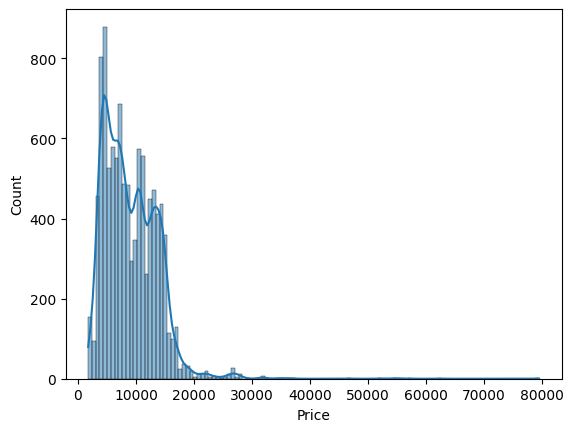

In [ ]:
sns.histplot(df["Price"],kde=True)
plt.show()


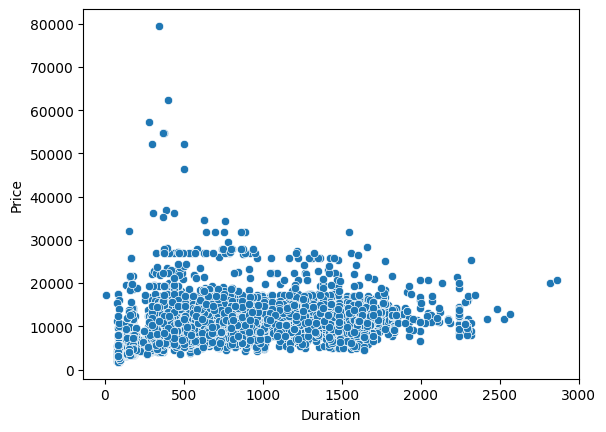

In [ ]:
sns.scatterplot(data=df,x="Duration",y="Price")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=["Airline", "Source", "Destination"], drop_first=True)

In [ ]:
df.head()

,Duration,Total_Stops,Price,Journey_Day,Journey_Month,Dep_Hour,Dep_Min,Arrival_Hour,Arrival_Min,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,170,0,3897,24,3,22,20,1,10,False,...,False,False,False,False,False,False,False,False,False,True
1,445,2,7662,1,5,5,50,13,15,True,...,False,False,False,True,False,False,False,False,False,False
2,1140,2,13882,9,6,9,25,4,25,False,...,False,False,True,False,False,True,False,False,False,False
3,325,1,6218,12,5,18,5,23,30,False,...,False,False,False,True,False,False,False,False,False,False
4,285,1,13302,1,3,16,50,21,35,False,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)
y = df["Price"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)

rf.fit(X_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
print("mae =",mean_absolute_error(y_test,pred))
print("mse =",np.sqrt(mean_squared_error(y_test,pred)))
print("r2 =",r2_score(y_test,pred))

mae = 1172.5082035545545
mse = 1967.820513856645
r2 = 0.8142797963648111


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Duration                                   10462 non-null  int64
 1   Total_Stops                                10462 non-null  int64
 2   Price                                      10462 non-null  int64
 3   Journey_Day                                10462 non-null  int32
 4   Journey_Month                              10462 non-null  int32
 5   Dep_Hour                                   10462 non-null  int32
 6   Dep_Min                                    10462 non-null  int32
 7   Arrival_Hour                               10462 non-null  int32
 8   Arrival_Min                                10462 non-null  int32
 9   Airline_Air India                          10462 non-null  bool 
 10  Airline_GoAir                              10462 no

In [ ]:
print(X.columns)

Index(['Duration', 'Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour',
       'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Airline_Air India',
       'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')


In [ ]:
print(X.columns.tolist())

['Duration', 'Total_Stops', 'Journey_Day', 'Journey_Month', 'Dep_Hour', 'Dep_Min', 'Arrival_Hour', 'Arrival_Min', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo', 'Airline_Jet Airways', 'Airline_Jet Airways Business', 'Airline_Multiple carriers', 'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet', 'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata', 'Destination_New Delhi']


In [ ]:
user_input = pd.DataFrame(0, index=[0], columns=X.columns)

user_input['Duration'] = int(input("Duration (minutes): "))
user_input['Total_Stops'] = int(input("Total Stops: "))
user_input['Journey_Day'] = int(input("Journey Day: "))
user_input['Journey_Month'] = int(input("Journey Month: "))

Duration (minutes): 125
Total Stops: 5
Journey Day: 2
Journey Month: 1


In [ ]:
prediction = rf.predict(user_input)

print("Predicted Flight Price: ₹", round(prediction[0], 2))

Predicted Flight Price: ₹ 9331.75
